# Customer Data Cleaning and Feature Engineering

Step-by-step flow:
- Step 1: load and inspect raw data
- Step 2: clean schema/types and build features
- Step 3: treat outliers, export final dataset, and run quick EDA

In [11]:
import sys
import subprocess

required_packages = ["numpy", "pandas", "matplotlib", "seaborn"]
subprocess.check_call([sys.executable, "-m", "pip", "install", "--user", *required_packages])

print("Packages installed for this notebook:", required_packages)
print("Python executable used by kernel:", sys.executable)

Packages installed for this notebook: ['numpy', 'pandas', 'matplotlib', 'seaborn']
Python executable used by kernel: /usr/local/bin/python3.13


In [12]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', 200)
pd.set_option('display.width', 140)

sns.set_theme(style='whitegrid')

In [13]:
# Risoluzione path robusta: funziona sia da src/ che dalla root del repo
# CRITICO: Path('.').resolve() per ottenere il path assoluto — Path('.').parent == Path('.') (non sale!)
from pathlib import Path

_HERE = Path('.').resolve()   # path assoluto della CWD (tipicamente Idea-Factory/src/ da Jupyter)

# Candidates per master_transactions.csv — sale fino a 3 livelli sopra
_candidates_master = [
    _HERE / 'master_transactions.csv',
    _HERE.parent / 'master_transactions.csv',               # Idea-Factory/
    _HERE.parent.parent / 'master_transactions.csv',        # data science in action/ ← posizione reale
    _HERE.parent.parent.parent / 'master_transactions.csv', # Desktop/ (fallback)
    _HERE / 'io' / 'master_transactions.csv',
    _HERE.parent / 'io' / 'master_transactions.csv',
]

MASTER_PATH = next((p for p in _candidates_master if p.exists()), None)

if MASTER_PATH is None:
    raise FileNotFoundError(
        "master_transactions.csv non trovato.\n"
        f"CWD assoluta: {_HERE}\n"
        "Copia master_transactions.csv nella cartella 'data science in action/'."
    )

BASE_DIR = MASTER_PATH.parent   # path assoluto alla cartella con i dati (usato per output)

print(f"Caricamento da: {MASTER_PATH}")
master = pd.read_csv(MASTER_PATH)

# Il dataset è già pre-joined (transazioni + cliente + prodotto + campagna email).
# Non esiste un customer.csv separato.
# 'custom' viene costruito estraendo le colonne demografiche per cliente dal master.
_DEMO_COLS = ['customer_id', 'Gender', 'Date_Of_Birth', 'province', 'subscription_date']
_available_demo = [c for c in _DEMO_COLS if c in master.columns]
custom = (
    master[_available_demo]
    .drop_duplicates(subset=['customer_id'])
    .reset_index(drop=True)
)

print(f"Transactions shape   : {master.shape}")
print(f"Customer demo shape  : {custom.shape}")
print(f"Colonne master       : {list(master.columns)}")
print(f"BASE_DIR (output)    : {BASE_DIR}")

Caricamento da: /Users/antonellamosca/Desktop/data science in action/master_transactions.csv
Transactions shape   : (102655, 24)
Customer demo shape  : (21480, 5)
Colonne master       : ['customer_id', 'Size', 'Quantity', 'Date', 'Payment_Method', 'list_price', 'store_channel', 'discount_percentage', 'line_amount', 'is_return', 'product_id', 'Gender', 'Date_Of_Birth', 'province_code', 'province', 'subscription_date', 'category', 'Sub_Category', 'gender', 'nl_count', 'nl_open_count', 'nl_click_count', 'nl_open_rate', 'nl_click_rate']
BASE_DIR (output)    : /Users/antonellamosca/Desktop/data science in action


## Step 1 - Initial Data Review
Check shape, sample rows, types, missing values, and duplicates.

In [14]:
display(master.head(3))
display(custom.head(3))

,customer_id,Size,Quantity,Date,Payment_Method,list_price,store_channel,discount_percentage,line_amount,is_return,product_id,Gender,Date_Of_Birth,province_code,province,subscription_date,category,Sub_Category,gender,nl_count,nl_open_count,nl_click_count,nl_open_rate,nl_click_rate
0,A0356882,XL,-1,03OCT2023,Card,286.0,E-commerce,0.0,-286.0,1,191533,M,1967-03-11,AL,Alessandria,17JUN2023,Outerwear,Suits,Man,12.0,4.0,0.0,0.333333,0.0
1,A0356882,XL,1,10SEP2023,Card,286.0,E-commerce,0.0,286.0,0,191533,M,1967-03-11,AL,Alessandria,17JUN2023,Outerwear,Suits,Man,12.0,4.0,0.0,0.333333,0.0
2,A0356882,S,1,17JUN2023,Card,258.0,E-commerce,0.0,258.0,0,195936,M,1967-03-11,AL,Alessandria,17JUN2023,Outerwear,Suits,Woman,12.0,4.0,0.0,0.333333,0.0


,customer_id,Gender,Date_Of_Birth,province,subscription_date
0,A0356882,M,1967-03-11,Alessandria,17JUN2023
1,A0357266,M,1973-07-15,Torino,05MAR2023
2,A0357328,M,1992-01-06,Bari,05SEP2023


In [15]:
master.info()
custom.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 102655 entries, 0 to 102654
Data columns (total 24 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   customer_id          102655 non-null  object 
 1   Size                 95913 non-null   object 
 2   Quantity             102655 non-null  int64  
 3   Date                 102655 non-null  object 
 4   Payment_Method       102655 non-null  object 
 5   list_price           102655 non-null  float64
 6   store_channel        102655 non-null  object 
 7   discount_percentage  102655 non-null  float64
 8   line_amount          102655 non-null  float64
 9   is_return            102655 non-null  int64  
 10  product_id           102655 non-null  int64  
 11  Gender               102655 non-null  object 
 12  Date_Of_Birth        102655 non-null  object 
 13  province_code        97796 non-null   object 
 14  province             102655 non-null  object 
 15  subscription_date

In [16]:
missing_master = master.isna().sum().sort_values(ascending=False)
missing_custom = custom.isna().sum().sort_values(ascending=False)

print('Top missing fields in transactions:')
display(missing_master.head(20).to_frame('missing_rows'))

print('\nMissing fields in customer table:')
display(missing_custom.to_frame('missing_rows'))

print(f'Transaction duplicates: {master.duplicated().sum()}')
print(f'Customer duplicates: {custom.duplicated().sum()}')

Top missing fields in transactions:


,missing_rows
nl_click_rate,11141
nl_open_rate,11141
nl_click_count,11141
nl_open_count,11141
nl_count,11141
Size,6742
province_code,4859
gender,0
Sub_Category,0
category,0



Missing fields in customer table:


,missing_rows
customer_id,0
Gender,0
Date_Of_Birth,0
province,0
subscription_date,0


Transaction duplicates: 34
Customer duplicates: 0


In [17]:
if 'cluster' in custom.columns:
    cluster_dist = custom['cluster'].value_counts(dropna=False).sort_index()
    print('Cluster distribution in customer table:')
    display(cluster_dist.to_frame('customers'))

    plt.figure(figsize=(7, 4))
    sns.countplot(data=custom, x='cluster', palette='Set2')
    plt.title('Cluster distribution')
    plt.show()

## Step 2 - Schema and Type Cleanup
Standardize column names and convert key fields to the correct data types.

In [18]:
def clean_column_names(df: pd.DataFrame) -> pd.DataFrame:
    cleaned = df.copy()
    cleaned.columns = (
        cleaned.columns
        .str.replace('\n', '', regex=False)
        .str.replace('\t', '', regex=False)
        .str.strip()
        .str.replace(' ', '_', regex=False)
    )
    return cleaned

master = clean_column_names(master)
custom = clean_column_names(custom)

print('Cleaned transaction columns:')
print(master.columns.tolist())

print('\nCleaned customer columns:')
print(custom.columns.tolist())

Cleaned transaction columns:
['customer_id', 'Size', 'Quantity', 'Date', 'Payment_Method', 'list_price', 'store_channel', 'discount_percentage', 'line_amount', 'is_return', 'product_id', 'Gender', 'Date_Of_Birth', 'province_code', 'province', 'subscription_date', 'category', 'Sub_Category', 'gender', 'nl_count', 'nl_open_count', 'nl_click_count', 'nl_open_rate', 'nl_click_rate']

Cleaned customer columns:
['customer_id', 'Gender', 'Date_Of_Birth', 'province', 'subscription_date']


In [19]:
# Main numeric coercion in transactions
numeric_master_candidates = [
    'Quantity', 'list_price', 'line_amount', 'discount_percentage',
    'nl_count', 'nl_open_count', 'nl_click_count', 'nl_open_rate', 'nl_click_rate'
]

for col in numeric_master_candidates:
    if col in master.columns:
        master[col] = pd.to_numeric(master[col], errors='coerce')

if 'Date' in master.columns:
    # Expected format example: 03OCT2023
    parsed = pd.to_datetime(master['Date'], format='%d%b%Y', errors='coerce')
    fallback = pd.to_datetime(master['Date'], errors='coerce')
    master['Date'] = parsed.fillna(fallback)

if 'Date_Of_Birth' in master.columns:
    master['Date_Of_Birth'] = pd.to_datetime(master['Date_Of_Birth'], errors='coerce')

if 'subscription_date' in master.columns:
    parsed_sub = pd.to_datetime(master['subscription_date'], format='%d%b%Y', errors='coerce')
    fallback_sub = pd.to_datetime(master['subscription_date'], errors='coerce')
    master['subscription_date'] = parsed_sub.fillna(fallback_sub)

numeric_custom = custom.select_dtypes(include=np.number).columns.tolist()
for col in numeric_custom:
    custom[col] = pd.to_numeric(custom[col], errors='coerce')

master = master.drop_duplicates().copy()
custom = custom.drop_duplicates(subset=['customer_id']).copy() if 'customer_id' in custom.columns else custom.drop_duplicates().copy()

print('Type conversion and deduplication completed.')

Type conversion and deduplication completed.


## Step 3 - Transaction-Level Features
Create helpful transaction metrics (value, discount, channel, and time features).

In [20]:
master_tx = master.copy()

if {'Quantity', 'list_price'}.issubset(master_tx.columns):
    master_tx['transaction_value_calculated'] = master_tx['Quantity'] * master_tx['list_price']
else:
    master_tx['transaction_value_calculated'] = np.nan

master_tx['abs_quantity'] = master_tx['Quantity'].abs() if 'Quantity' in master_tx.columns else np.nan

if 'discount_percentage' in master_tx.columns:
    master_tx['is_discounted'] = (master_tx['discount_percentage'] > 0).astype(int)
    master_tx['discount_value'] = (
        master_tx['list_price']
        * master_tx['abs_quantity']
        * (master_tx['discount_percentage'].fillna(0) / 100)
    ).fillna(0)
else:
    master_tx['is_discounted'] = 0
    master_tx['discount_value'] = 0.0

if 'store_channel' in master_tx.columns:
    channel_l = master_tx['store_channel'].astype(str).str.lower().str.strip()
    master_tx['is_ecommerce'] = channel_l.str.contains('e-?commerce', regex=True, na=False).astype(int)
    master_tx['is_store'] = (1 - master_tx['is_ecommerce']).astype(int)
else:
    master_tx['is_ecommerce'] = 0
    master_tx['is_store'] = 0

if 'Date' in master_tx.columns:
    master_tx['weekday'] = master_tx['Date'].dt.day_name()
    master_tx['month'] = master_tx['Date'].dt.month
    master_tx['year'] = master_tx['Date'].dt.year
    master_tx['is_weekend'] = master_tx['Date'].dt.dayofweek.isin([5, 6]).astype(int)
else:
    master_tx['weekday'] = np.nan
    master_tx['month'] = np.nan
    master_tx['year'] = np.nan
    master_tx['is_weekend'] = np.nan

display(
    master_tx[[
        'customer_id', 'Quantity', 'list_price', 'transaction_value_calculated',
        'is_discounted', 'discount_value', 'is_ecommerce', 'month'
    ]].head(5)
)

,customer_id,Quantity,list_price,transaction_value_calculated,is_discounted,discount_value,is_ecommerce,month
0,A0356882,-1,286.0,-286.0,0,0.0,1,10
1,A0356882,1,286.0,286.0,0,0.0,1,9
2,A0356882,1,258.0,258.0,0,0.0,1,6
3,A0356882,-1,258.0,-258.0,0,0.0,1,7
4,A0356882,1,211.0,211.0,0,0.0,1,3


## Step 4 - Customer-Level Features
Aggregate transactions into customer behavior and lifecycle features.

In [21]:
required = ['customer_id']
missing_req = [c for c in required if c not in master_tx.columns]
if missing_req:
    raise ValueError(f'Missing required columns in transactions: {missing_req}')

m = master_tx.copy()

m['tx_value_abs'] = m['transaction_value_calculated'].abs()
m['is_return_tx'] = (m.get('Quantity', 0) < 0).astype(int)
m['positive_value'] = np.where(m['transaction_value_calculated'] > 0, m['transaction_value_calculated'], 0)
m['return_value_abs'] = np.where(m['transaction_value_calculated'] < 0, -m['transaction_value_calculated'], 0)
m['positive_qty'] = np.where(m.get('Quantity', 0) > 0, m['Quantity'], 0)
m['return_qty_abs'] = np.where(m.get('Quantity', 0) < 0, -m['Quantity'], 0)

customer_agg = m.groupby('customer_id').agg(
    gross_spend=('positive_value', 'sum'),
    return_value=('return_value_abs', 'sum'),
    net_spend_recalc=('transaction_value_calculated', 'sum'),
    total_qty=('positive_qty', 'sum'),
    return_qty=('return_qty_abs', 'sum'),
    transaction_count_recalc=('customer_id', 'size'),
    avg_ticket=('transaction_value_calculated', 'mean'),
    median_ticket=('transaction_value_calculated', 'median'),
    max_ticket=('transaction_value_calculated', 'max'),
    min_ticket=('transaction_value_calculated', 'min'),
    price_mean=('list_price', 'mean'),
    price_std=('list_price', 'std'),
    discount_pct_mean=('discount_percentage', 'mean'),
    discounted_tx_rate=('is_discounted', 'mean'),
    unique_categories=('category', pd.Series.nunique) if 'category' in m.columns else ('customer_id', 'size'),
    unique_subcategories=('Sub_Category', pd.Series.nunique) if 'Sub_Category' in m.columns else ('customer_id', 'size'),
    ecommerce_share=('is_ecommerce', 'mean'),
    store_share=('is_store', 'mean')
).reset_index()

customer_agg['return_rate_qty'] = np.where(
    customer_agg['total_qty'] > 0,
    customer_agg['return_qty'] / customer_agg['total_qty'],
    0
)

if 'Date' in m.columns:
    max_date = m['Date'].max()
    time_agg = m.groupby('customer_id').agg(
        first_purchase=('Date', 'min'),
        last_purchase=('Date', 'max'),
        active_months=('month', pd.Series.nunique)
    ).reset_index()

    time_agg['recency_days'] = (max_date - time_agg['last_purchase']).dt.days
    time_agg['tenure_days'] = (time_agg['last_purchase'] - time_agg['first_purchase']).dt.days
    time_agg['tenure_days'] = time_agg['tenure_days'].clip(lower=0)
    time_agg['active_months'] = time_agg['active_months'].fillna(1).clip(lower=1)

    customer_agg = customer_agg.merge(
        time_agg[['customer_id', 'recency_days', 'tenure_days', 'active_months']],
        on='customer_id',
        how='left'
    )
else:
    customer_agg['recency_days'] = np.nan
    customer_agg['tenure_days'] = np.nan
    customer_agg['active_months'] = np.nan

customer_agg['purchase_frequency_per_month'] = np.where(
    customer_agg['active_months'] > 0,
    customer_agg['transaction_count_recalc'] / customer_agg['active_months'],
    np.nan
)

if 'store_channel' in m.columns:
    dominant_channel = (
        m.groupby(['customer_id', 'store_channel'])
        .size()
        .reset_index(name='channel_count')
        .sort_values(['customer_id', 'channel_count'], ascending=[True, False])
        .drop_duplicates('customer_id')
        [['customer_id', 'store_channel']]
        .rename(columns={'store_channel': 'dominant_channel'})
    )
    customer_agg = customer_agg.merge(dominant_channel, on='customer_id', how='left')
else:
    customer_agg['dominant_channel'] = np.nan

display(customer_agg.head(5))

,customer_id,gross_spend,return_value,net_spend_recalc,total_qty,return_qty,transaction_count_recalc,avg_ticket,median_ticket,max_ticket,min_ticket,price_mean,price_std,discount_pct_mean,discounted_tx_rate,unique_categories,unique_subcategories,ecommerce_share,store_share,return_rate_qty,recency_days,tenure_days,active_months,purchase_frequency_per_month,dominant_channel
0,A0356882,1366.0,1231.5,134.5,9,8,17,7.911765,56.00,286.0,-286.0,152.794118,87.186951,0.032353,0.058824,6,8,1.0,0.0,0.888889,33,589,9,1.888889,E-commerce
1,A0357266,1187.0,797.0,390.0,10,7,13,30.000000,72.00,370.5,-370.5,114.615385,41.351720,0.026923,0.076923,4,7,1.0,0.0,0.700000,30,696,8,1.625000,E-commerce
2,A0357328,863.5,437.0,426.5,8,5,10,42.650000,62.75,364.0,-224.0,89.450000,37.665524,0.045000,0.100000,3,6,1.0,0.0,0.625000,69,473,5,2.000000,E-commerce
3,A0357849,616.0,298.5,317.5,4,2,6,52.916667,106.50,209.0,-194.0,152.416667,51.343370,0.000000,0.000000,3,4,1.0,0.0,0.500000,20,408,4,1.500000,E-commerce
4,A0358076,1171.0,530.5,640.5,10,5,15,42.700000,77.00,242.0,-163.5,113.433333,52.989846,0.013333,0.066667,7,9,1.0,0.0,0.500000,532,156,4,3.750000,E-commerce


## Step 5 - Merge Customer Datasets
Join existing customer data with newly engineered customer features.

In [22]:
if 'customer_id' not in custom.columns:
    raise ValueError('customer_id is missing in the customer dataset')

df_merged = custom.merge(customer_agg, on='customer_id', how='left')

print(f'Shape after merge: {df_merged.shape}')
display(df_merged.head(3))

Shape after merge: (21480, 29)


,customer_id,Gender,Date_Of_Birth,province,subscription_date,gross_spend,return_value,net_spend_recalc,total_qty,return_qty,transaction_count_recalc,avg_ticket,median_ticket,max_ticket,min_ticket,price_mean,price_std,discount_pct_mean,discounted_tx_rate,unique_categories,unique_subcategories,ecommerce_share,store_share,return_rate_qty,recency_days,tenure_days,active_months,purchase_frequency_per_month,dominant_channel
0,A0356882,M,1967-03-11,Alessandria,17JUN2023,1366.0,1231.5,134.5,9,8,17,7.911765,56.00,286.0,-286.0,152.794118,87.186951,0.032353,0.058824,6,8,1.0,0.0,0.888889,33,589,9,1.888889,E-commerce
1,A0357266,M,1973-07-15,Torino,05MAR2023,1187.0,797.0,390.0,10,7,13,30.000000,72.00,370.5,-370.5,114.615385,41.351720,0.026923,0.076923,4,7,1.0,0.0,0.700000,30,696,8,1.625000,E-commerce
2,A0357328,M,1992-01-06,Bari,05SEP2023,863.5,437.0,426.5,8,5,10,42.650000,62.75,364.0,-224.0,89.450000,37.665524,0.045000,0.100000,3,6,1.0,0.0,0.625000,69,473,5,2.000000,E-commerce


## Step 6 - Outlier Treatment (IQR)
Detect outliers and create uncapped/capped versions of the dataset.

In [23]:
exclude_cols = {'customer_id', 'cluster'}
numeric_cols = [c for c in df_merged.select_dtypes(include=np.number).columns if c not in exclude_cols]

bounds = []
df_uncapped = df_merged.copy()
df_capped = df_merged.copy()

for col in numeric_cols:
    s = df_uncapped[col].dropna()
    if s.empty:
        continue

    q1 = s.quantile(0.25)
    q3 = s.quantile(0.75)
    iqr = q3 - q1

    if iqr == 0:
        lower = s.min()
        upper = s.max()
        outlier_mask = pd.Series(False, index=df_uncapped.index)
        treatment = 'skip_iqr_zero'
    else:
        lower = q1 - 1.5 * iqr
        upper = q3 + 1.5 * iqr
        outlier_mask = (df_uncapped[col] < lower) | (df_uncapped[col] > upper)
        df_capped[col] = df_capped[col].clip(lower=lower, upper=upper)
        treatment = 'iqr_cap'

    df_uncapped[f'{col}_is_outlier'] = outlier_mask.astype(int)

    bounds.append({
        'feature': col,
        'q1': q1,
        'q3': q3,
        'iqr': iqr,
        'lower_bound': lower,
        'upper_bound': upper,
        'outlier_count': int(outlier_mask.sum()),
        'outlier_share': float(outlier_mask.mean()),
        'treatment': treatment
    })

outlier_flag_cols = [c for c in df_uncapped.columns if c.endswith('_is_outlier')]
if outlier_flag_cols:
    df_uncapped['outlier_count'] = df_uncapped[outlier_flag_cols].sum(axis=1)
    df_uncapped['outlier_share'] = df_uncapped['outlier_count'] / len(outlier_flag_cols)
    df_capped['outlier_count'] = df_uncapped['outlier_count']
    df_capped['outlier_share'] = df_uncapped['outlier_share']

bounds_df = pd.DataFrame(bounds).sort_values('outlier_count', ascending=False)
display(bounds_df.head(20))

,feature,q1,q3,iqr,lower_bound,upper_bound,outlier_count,outlier_share,treatment
9,min_ticket,41.500000,101.500000,60.000000,-48.500000,191.500000,4369,0.203399,iqr_cap
7,median_ticket,91.750000,149.000000,57.250000,5.875000,234.875000,1632,0.075978,iqr_cap
5,transaction_count_recalc,2.000000,6.000000,4.000000,-4.000000,12.000000,1324,0.061639,iqr_cap
2,net_spend_recalc,184.000000,801.000000,617.000000,-741.500000,1726.500000,1035,0.048184,iqr_cap
0,gross_spend,207.875000,864.000000,656.125000,-776.312500,1848.187500,1020,0.047486,iqr_cap
22,purchase_frequency_per_month,1.000000,2.000000,1.000000,-0.500000,3.500000,969,0.045112,iqr_cap
8,max_ticket,134.500000,282.500000,148.000000,-87.500000,504.500000,933,0.043436,iqr_cap
12,discount_pct_mean,0.000000,0.190000,0.190000,-0.285000,0.475000,908,0.042272,iqr_cap
3,total_qty,2.000000,7.000000,5.000000,-5.500000,14.500000,873,0.040642,iqr_cap
6,avg_ticket,92.000000,160.750000,68.750000,-11.125000,263.875000,855,0.039804,iqr_cap


## Step 7 - Compare Before vs After Capping
Use summary statistics and boxplots to assess outlier treatment impact.

In [24]:
compare_cols = [
    c for c in ['net_amount', 'transaction_count', 'gross_spend', 'return_rate_qty', 'avg_ticket', 'recency_days']
    if c in df_uncapped.columns
]

print('UNCAPPED summary stats:')
display(df_uncapped[compare_cols].describe().T if compare_cols else pd.DataFrame())

print('\nCAPPED summary stats:')
display(df_capped[compare_cols].describe().T if compare_cols else pd.DataFrame())

UNCAPPED summary stats:


,count,mean,std,min,25%,50%,75%,max
gross_spend,21480.0,635.759195,604.995282,0.0,207.875,448.5,864.00,6163.0
return_rate_qty,21480.0,0.070195,0.206182,0.0,0.000,0.0,0.00,2.0
avg_ticket,21480.0,131.177419,69.736630,-115.0,92.000,125.0,160.75,1207.5
recency_days,21480.0,198.473557,177.814221,0.0,62.000,126.0,317.00,730.0



CAPPED summary stats:


,count,mean,std,min,25%,50%,75%,max
gross_spend,21480.0,604.884649,500.769171,0.000,207.875,448.5,864.00,1848.1875
return_rate_qty,21480.0,0.070195,0.206182,0.000,0.000,0.0,0.00,2.0000
avg_ticket,21480.0,128.166385,58.288277,-11.125,92.000,125.0,160.75,263.8750
recency_days,21480.0,198.355959,177.476218,0.000,62.000,126.0,317.00,699.5000


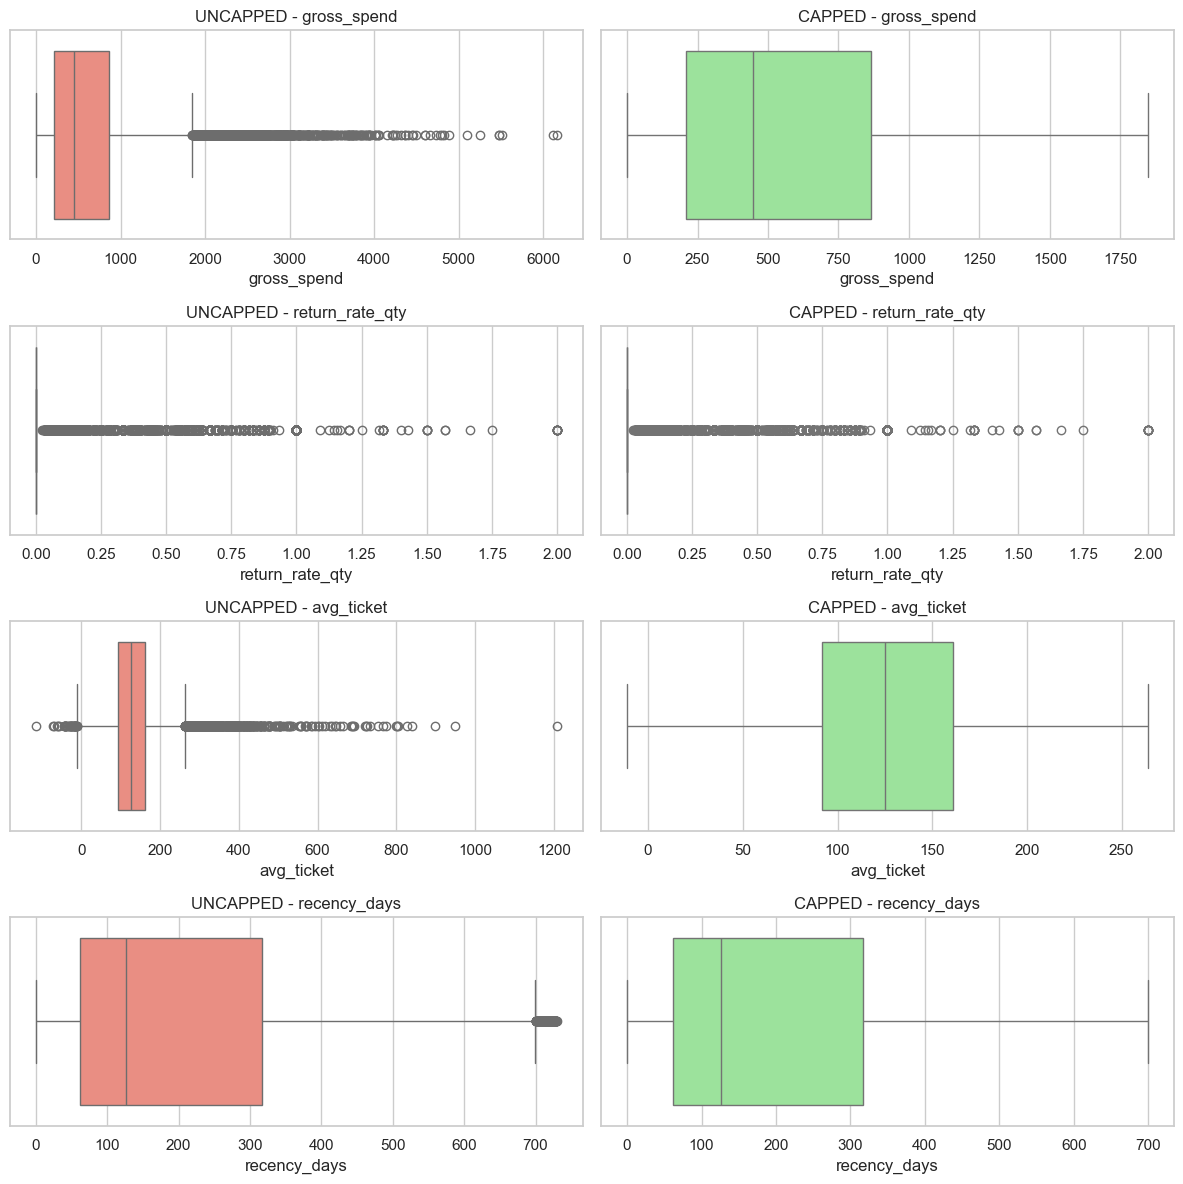

In [25]:
if compare_cols:
    n = len(compare_cols)
    fig, axes = plt.subplots(nrows=n, ncols=2, figsize=(12, max(3 * n, 4)))
    if n == 1:
        axes = np.array([axes])

    for i, col in enumerate(compare_cols):
        sns.boxplot(x=df_uncapped[col], ax=axes[i, 0], color='salmon')
        axes[i, 0].set_title(f'UNCAPPED - {col}')

        sns.boxplot(x=df_capped[col], ax=axes[i, 1], color='lightgreen')
        axes[i, 1].set_title(f'CAPPED - {col}')

    plt.tight_layout()
    plt.show()

## Step 8 - Export Final Dataset
Apply final business rules and export the clean analysis-ready file.

In [26]:
FINAL_OUT = BASE_DIR / 'customer_features_final_clean.csv'

# Analysis-ready output: start from capped data.
df_final = df_capped.copy()

# 1) Business rules for ratio columns: clamp to [0, 1].
rate_share_cols = [
    c for c in df_final.columns
    if ('rate' in c.lower()) or ('share' in c.lower())
]
for col in rate_share_cols:
    s = pd.to_numeric(df_final[col], errors='coerce')
    df_final[col] = s.clip(lower=0, upper=1)

# 2) Features that should never be negative.
non_negative_cols = [
    'age_years', 'net_quantity', 'transaction_count', 'return_tx_count',
    'gross_spend', 'return_value', 'total_qty', 'return_qty',
    'transaction_count_recalc', 'unique_categories', 'unique_subcategories',
    'active_months', 'recency_days', 'tenure_days', 'purchase_frequency_per_month'
 ]
for col in non_negative_cols:
    if col in df_final.columns:
        s = pd.to_numeric(df_final[col], errors='coerce')
        df_final[col] = s.clip(lower=0)

# 3) Handle missing values in price_std and keep traceability.
if 'price_std' in df_final.columns:
    df_final['price_std_missing_flag'] = df_final['price_std'].isna().astype(int)
    median_price_std = df_final['price_std'].median()
    df_final['price_std'] = df_final['price_std'].fillna(median_price_std)

df_final.to_csv(FINAL_OUT, index=False)

# Quick checks after business rules.
remaining_outliers = 0
for _, r in bounds_df.iterrows():
    col = r['feature']
    lb = r['lower_bound']
    ub = r['upper_bound']
    if col in df_final.columns:
        m = (df_final[col] < lb) | (df_final[col] > ub)
        remaining_outliers += int(m.sum())

bad_rate_rows = 0
for col in rate_share_cols:
    s = pd.to_numeric(df_final[col], errors='coerce')
    bad_rate_rows += int(((s < 0) | (s > 1)).sum())

neg_count = 0
for col in non_negative_cols:
    if col in df_final.columns:
        s = pd.to_numeric(df_final[col], errors='coerce')
        neg_count += int((s < 0).sum())

print('Exported files:')
print(f'- {FINAL_OUT}')
print(f'Residual outliers vs IQR bounds (informational): {remaining_outliers}')
print(f'Values outside [0,1] on rate/share columns (expected 0): {bad_rate_rows}')
print(f'Negative values on non-negative columns (expected 0): {neg_count}')
if 'price_std_missing_flag' in df_final.columns:
    print('Originally missing price_std rows:', int(df_final['price_std_missing_flag'].sum()))

Exported files:
- /Users/antonellamosca/Desktop/data science in action/customer_features_final_clean.csv
Residual outliers vs IQR bounds (informational): 0
Values outside [0,1] on rate/share columns (expected 0): 0
Negative values on non-negative columns (expected 0): 0
Originally missing price_std rows: 4728


## Step 9 - Final Quality Notes

Checklist:
- Date/type cleanup completed
- Duplicates removed
- Features engineered
- Outliers treated and rules applied
- Final dataset exported

Final dataset loaded from: /Users/antonellamosca/Desktop/data science in action/customer_features_final_clean.csv
Shape: (21480, 32)
Duplicate customer_id values: 0


,customer_id,Gender,Date_Of_Birth,province,subscription_date,gross_spend,return_value,net_spend_recalc,total_qty,return_qty,transaction_count_recalc,avg_ticket,median_ticket,max_ticket,min_ticket,price_mean,price_std,discount_pct_mean,discounted_tx_rate,unique_categories,unique_subcategories,ecommerce_share,store_share,return_rate_qty,recency_days,tenure_days,active_months,purchase_frequency_per_month,dominant_channel,outlier_count,outlier_share,price_std_missing_flag
0,A0356882,M,1967-03-11,Alessandria,17JUN2023,1366.0,1231.5,134.5,9.0,8,12,7.911765,56.00,286.0,-48.5,152.794118,87.186951,0.032353,0.058824,6,8.0,1.0,0.0,0.888889,33.0,589,8.5,1.888889,E-commerce,3,0.130435,0
1,A0357266,M,1973-07-15,Torino,05MAR2023,1187.0,797.0,390.0,10.0,7,12,30.000000,72.00,370.5,-48.5,114.615385,41.351720,0.026923,0.076923,4,7.0,1.0,0.0,0.700000,30.0,696,8.0,1.625000,E-commerce,2,0.086957,0
2,A0357328,M,1992-01-06,Bari,05SEP2023,863.5,437.0,426.5,8.0,5,10,42.650000,62.75,364.0,-48.5,89.450000,37.665524,0.045000,0.100000,3,6.0,1.0,0.0,0.625000,69.0,473,5.0,2.000000,E-commerce,1,0.043478,0



Missing percentage (top 15):


,missing_pct
customer_id,0.0
Gender,0.0
outlier_share,0.0
outlier_count,0.0
dominant_channel,0.0
purchase_frequency_per_month,0.0
active_months,0.0
tenure_days,0.0
recency_days,0.0
return_rate_qty,0.0



Key descriptive statistics:


,count,mean,std,min,25%,50%,75%,max
gross_spend,21480.0,604.884649,500.769171,0.000,207.875000,448.500000,864.000000,1848.187500
return_rate_qty,21480.0,0.069393,0.201140,0.000,0.000000,0.000000,0.000000,1.000000
avg_ticket,21480.0,128.166385,58.288277,-11.125,92.000000,125.000000,160.750000,263.875000
recency_days,21480.0,198.355959,177.476218,0.000,62.000000,126.000000,317.000000,699.500000
purchase_frequency_per_month,21480.0,1.600587,0.740208,1.000,1.000000,1.333333,2.000000,3.500000
price_std,21480.0,57.646109,28.093006,0.000,41.570849,55.991673,71.171984,142.539884


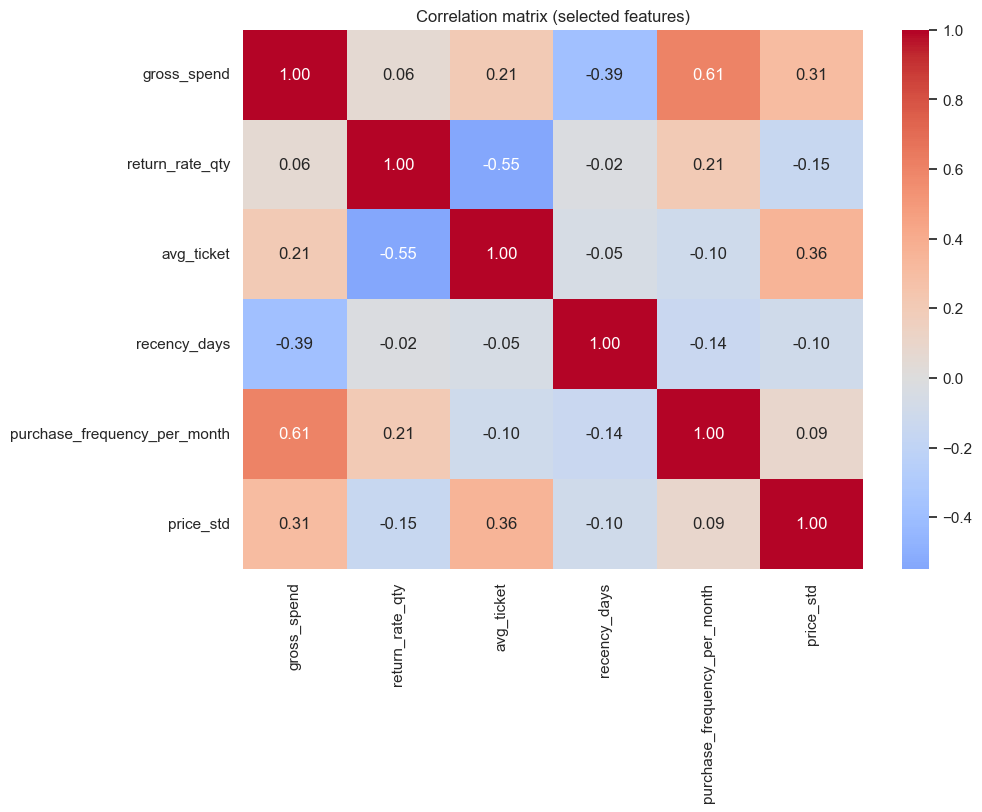

In [27]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# BASE_DIR è già definito nella cella di caricamento dati (path assoluto)
FINAL_EDA_PATH = BASE_DIR / 'customer_features_final_clean.csv'
df_eda = pd.read_csv(FINAL_EDA_PATH)

print('Final dataset loaded from:', FINAL_EDA_PATH)
print('Shape:', df_eda.shape)
print('Duplicate customer_id values:', int(df_eda['customer_id'].duplicated().sum()) if 'customer_id' in df_eda.columns else 'N/A')

display(df_eda.head(3))

print('\nMissing percentage (top 15):')
missing_pct = (df_eda.isna().mean() * 100).sort_values(ascending=False)
display(missing_pct.head(15).to_frame('missing_pct'))

num_cols = df_eda.select_dtypes(include=np.number).columns.tolist()
eda_cols = [c for c in [
    'net_amount', 'transaction_count', 'gross_spend', 'return_rate_qty',
    'avg_ticket', 'recency_days', 'purchase_frequency_per_month', 'price_std'
] if c in df_eda.columns]

print('\nKey descriptive statistics:')
display(df_eda[eda_cols].describe().T if eda_cols else pd.DataFrame())

if 'cluster' in df_eda.columns and eda_cols:
    print('\nFeature means by cluster:')
    cluster_summary = df_eda.groupby('cluster')[eda_cols].mean().round(3)
    display(cluster_summary)

    fig, axes = plt.subplots(nrows=len(eda_cols), ncols=1, figsize=(10, max(4, 3 * len(eda_cols))))
    if len(eda_cols) == 1:
        axes = [axes]

    for i, col in enumerate(eda_cols):
        sns.boxplot(data=df_eda, x='cluster', y=col, ax=axes[i], palette='Set2')
        axes[i].set_title(f'{col} by cluster')

    plt.tight_layout()
    plt.show()

if len(num_cols) >= 2:
    corr_cols = [c for c in [
        'net_amount', 'transaction_count', 'gross_spend', 'return_rate_qty',
        'avg_ticket', 'recency_days', 'purchase_frequency_per_month', 'price_std',
        'nl_open_rate', 'nl_click_rate'
    ] if c in num_cols]

    if len(corr_cols) >= 2:
        corr = df_eda[corr_cols].corr()
        plt.figure(figsize=(10, 7))
        sns.heatmap(corr, cmap='coolwarm', center=0, annot=True, fmt='.2f')
        plt.title('Correlation matrix (selected features)')
        plt.show()

## Step 10 - Quick EDA
Review distributions, cluster differences, and feature correlations.